In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [15]:
# Define the state structure
class BMIState(TypedDict):
    height_m: int
    weight_kg: float
    bmi: float
    category: str


In [9]:
def calculate_bmi(state: BMIState) -> BMIState:
    bmi = state['weight_kg'] / (state['height_m']**2)
    state['bmi'] = bmi
    return state

In [17]:
#get bmi category
def get_bmi_category(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 24.9:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 29.9:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obesity'
    return state

In [18]:
# define your graph
graph = StateGraph(BMIState)
# add nodes to your graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('category', get_bmi_category)
#add edges
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'category')
graph.add_edge('category',END)


In [19]:
#compile graph
workflow = graph.compile()

In [20]:
#execute workflow
initial_state = {'weight_kg':70, 'height_m':1.65}
output_state = workflow.invoke(initial_state)
output_state

{'height_m': 1.65,
 'weight_kg': 70,
 'bmi': 25.71166207529844,
 'category': 'Overweight'}

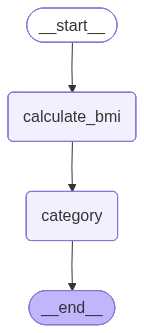

In [21]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())